In [4]:
import kagglehub

path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

print("Path to dataset files: path", path)

Using Colab cache for faster access to the 'ai-vs-real-images-dataset' dataset.
Path to dataset files: path /kaggle/input/ai-vs-real-images-dataset


In [5]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# ── 2. Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 3. Dataset Path ───────────────────────────────────────────────────────────
dataset_path = '/content/drive/MyDrive/CUDA Workshop Hackathon/archive'

# Verify the folder exists and show structure
print("📁 Folder contents:")
for entry in os.listdir(dataset_path):
    subpath = os.path.join(dataset_path, entry)
    if os.path.isdir(subpath):
        count = len([f for f in os.listdir(subpath) if os.path.isfile(os.path.join(subpath, f))])
        print(f"   └── {entry}/  ({count} files)")
    else:
        print(f"   └── {entry}")

# ── 4. Transforms ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# No augmentation for val/test — only resize, tensor, normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── 5. Load Full Dataset ──────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=dataset_path)

print(f"\n✅ Classes found : {full_dataset.classes}")
print(f"   Class mapping  : {full_dataset.class_to_idx}")
print(f"   Total images   : {len(full_dataset)}")

# ── 6. Train / Val / Test Split (80 / 10 / 10) ───────────────────────────────
total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)   # reproducible splits
)

print(f"\n📊 Split sizes:")
print(f"   Train : {len(train_ds)}")
print(f"   Val   : {len(val_ds)}")
print(f"   Test  : {len(test_ds)}")

# ── 7. Apply Transforms Per Split ─────────────────────────────────────────────
# random_split doesn't support per-subset transforms directly,
# so we wrap each subset with the correct transform
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        # img is a PIL image because full_dataset has no transform set
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = TransformSubset(train_ds, train_transform)
val_ds   = TransformSubset(val_ds,   val_test_transform)
test_ds  = TransformSubset(test_ds,  val_test_transform)

# ── 8. DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n🚀 DataLoaders ready:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# ── 9. Device ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n💻 Device: {device}")

Mounted at /content/drive
📁 Folder contents:
   └── real_dataset/  (0 files)
   └── Ai_generated_dataset/  (0 files)

✅ Classes found : ['Ai_generated_dataset', 'real_dataset']
   Class mapping  : {'Ai_generated_dataset': 0, 'real_dataset': 1}
   Total images   : 995

📊 Split sizes:
   Train : 796
   Val   : 99
   Test  : 100

🚀 DataLoaders ready:
   Train batches : 25
   Val batches   : 4
   Test batches  : 4

💻 Device: cuda


In [6]:
# ── 1. Update Dataset Path (fix folder name) ──────────────────────────────────
dataset_path = '/content/drive/MyDrive/CUDA Workshop Hackathon/archive'

# ── 2. Build Model ────────────────────────────────────────────────────────────
def build_model(num_classes=2, freeze_backbone=True):
    # Load pretrained EfficientNet-B3
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the classifier head
    in_features = model.classifier[1].in_features  # 1536 for B3
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.2),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )
    return model

# ── 3. Instantiate & Move to Device ───────────────────────────────────────────
model = build_model(num_classes=2, freeze_backbone=True).to(device)

# ── 4. Sanity Check — forward pass with a dummy batch ─────────────────────────
dummy_input = torch.randn(4, 3, 224, 224).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"✅ Model output shape : {dummy_output.shape}")   # expect [4, 2]
print(f"   Output (logits)    : {dummy_output}")

# ── 5. Count Parameters ───────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\n📊 Parameter counts:")
print(f"   Total      : {total_params:,}")
print(f"   Trainable  : {trainable_params:,}  ← only the new head")
print(f"   Frozen     : {frozen_params:,}  ← EfficientNet backbone")

# ── 6. Loss, Optimizer, Scheduler ─────────────────────────────────────────────
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Stage 1: only train the head (backbone frozen)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

print(f"\n⚙️  Optimizer  : AdamW  (lr=1e-3, weight_decay=1e-4)")
print(f"   Scheduler  : CosineAnnealingLR  (T_max=10)")
print(f"   Loss       : CrossEntropyLoss   (label_smoothing=0.1)")
print(f"\n🚀 Ready for Stage 1 training (frozen backbone)!")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 207MB/s]


✅ Model output shape : torch.Size([4, 2])
   Output (logits)    : tensor([[-0.0975,  0.1849],
        [-0.0722,  0.1257],
        [ 0.0582, -0.3186],
        [ 0.2824, -0.1114]], device='cuda:0')

📊 Parameter counts:
   Total      : 11,550,122
   Trainable  : 853,890  ← only the new head
   Frozen     : 10,696,232  ← EfficientNet backbone

⚙️  Optimizer  : AdamW  (lr=1e-3, weight_decay=1e-4)
   Scheduler  : CosineAnnealingLR  (T_max=10)
   Loss       : CrossEntropyLoss   (label_smoothing=0.1)

🚀 Ready for Stage 1 training (frozen backbone)!


🔒 Stage 1: Training classifier head with frozen backbone...


  Stage 1 Training — 15 epochs max, patience=5

── Epoch 1/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.3490 Acc: 0.7188
   Batch [20/25] Loss: 0.4262 Acc: 0.8000

   ⏱  159.2s  |  Train Loss: 0.4471  Train Acc: 0.8229  |  Val Loss: 0.3029  Val Acc: 0.9899
   ✅ New best val acc: 0.9899 — model saved.
── Epoch 2/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.3262 Acc: 0.9219
   Batch [20/25] Loss: 0.2728 Acc: 0.9250

   ⏱  21.8s  |  Train Loss: 0.3249  Train Acc: 0.9296  |  Val Loss: 0.2430  Val Acc: 0.9798
   ⏳ No improvement. Patience: 1/5
── Epoch 3/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.3317 Acc: 0.9156
   Batch [20/25] Loss: 0.2845 Acc: 0.9203

   ⏱  24.6s  |  Train Loss: 0.3190  Train Acc: 0.9284  |  Val Loss: 0.2343  Val Acc: 0.9899
   ⏳ No improvement. Patience: 2/5
── Epoch 4/15 ────────────────────────────────────────
   Batch [10/25] Loss: 

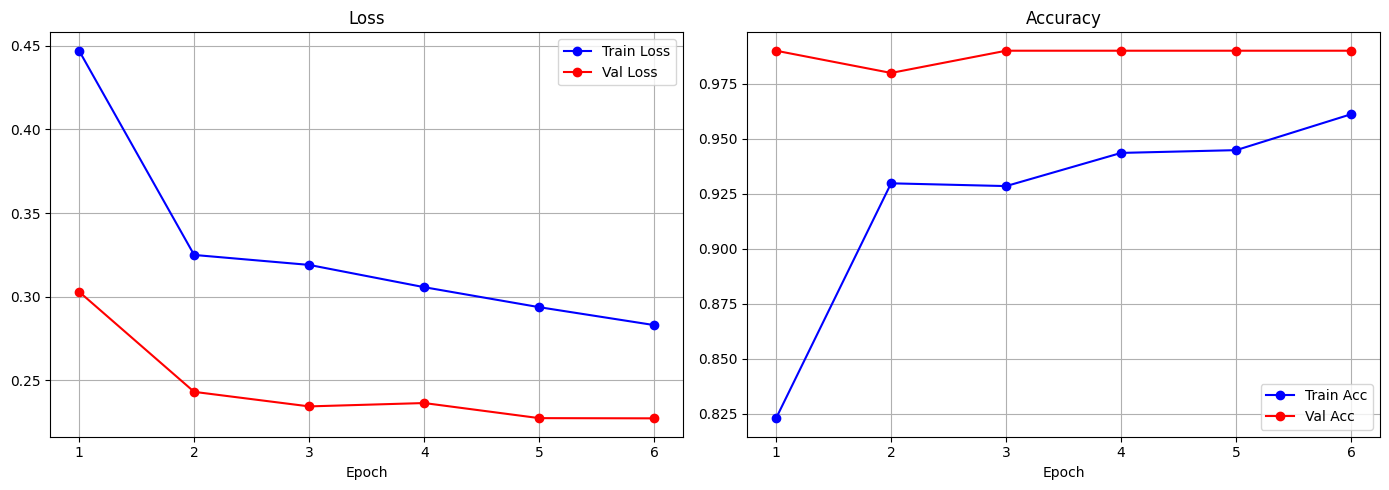

📊 Training curves saved to Drive.

🔓 Stage 2: Unfreezing backbone for full fine-tuning...


  Stage 2 Training — 15 epochs max, patience=5

── Epoch 1/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.3590 Acc: 0.9062
   Batch [20/25] Loss: 0.2875 Acc: 0.9219

   ⏱  24.4s  |  Train Loss: 0.3339  Train Acc: 0.9183  |  Val Loss: 0.2497  Val Acc: 0.9798
   ✅ New best val acc: 0.9798 — model saved.
── Epoch 2/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.2993 Acc: 0.9281
   Batch [20/25] Loss: 0.3562 Acc: 0.9281

   ⏱  25.8s  |  Train Loss: 0.3199  Train Acc: 0.9246  |  Val Loss: 0.2445  Val Acc: 0.9899
   ✅ New best val acc: 0.9899 — model saved.
── Epoch 3/15 ────────────────────────────────────────
   Batch [10/25] Loss: 0.2801 Acc: 0.9625
   Batch [20/25] Loss: 0.2838 Acc: 0.9516

   ⏱  26.5s  |  Train Loss: 0.3099  Train Acc: 0.9510  |  Val Loss: 0.2399  Val Acc: 0.9899
   ⏳ No improvement. Patience: 1/5
── Epoch 4/15 ─────────────────────────

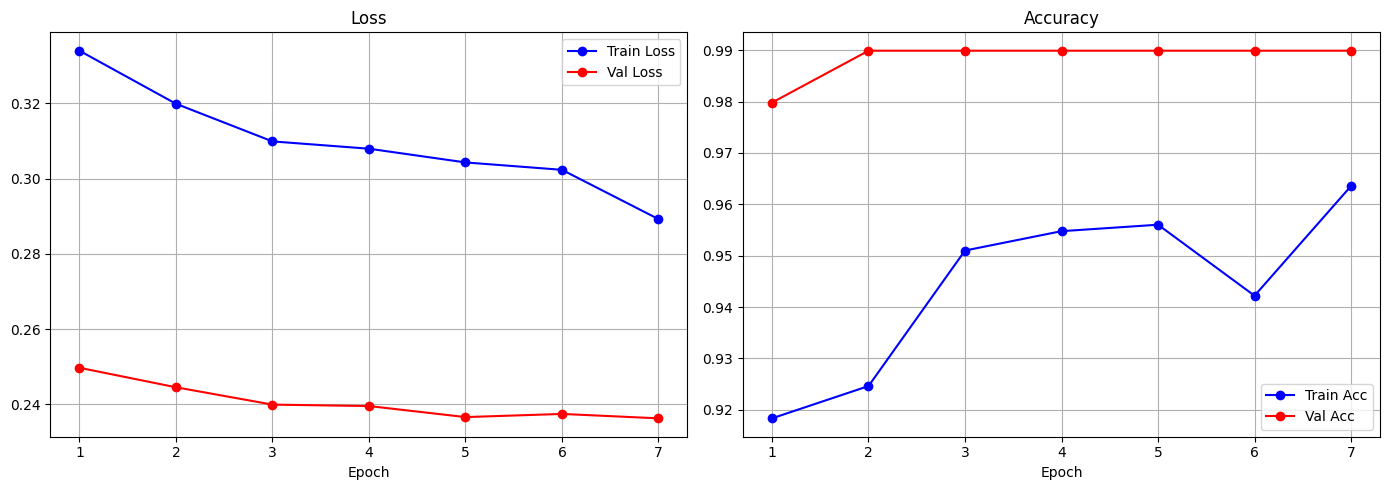

📊 Training curves saved to Drive.

📋 Final Evaluation on Test Set...

🎯 Test Loss : 0.2793
   Test Acc  : 0.9600

📝 Classification Report:
                      precision    recall  f1-score   support

Ai_generated_dataset       0.86      0.95      0.90        20
        real_dataset       0.99      0.96      0.97        80

            accuracy                           0.96       100
           macro avg       0.93      0.96      0.94       100
        weighted avg       0.96      0.96      0.96       100



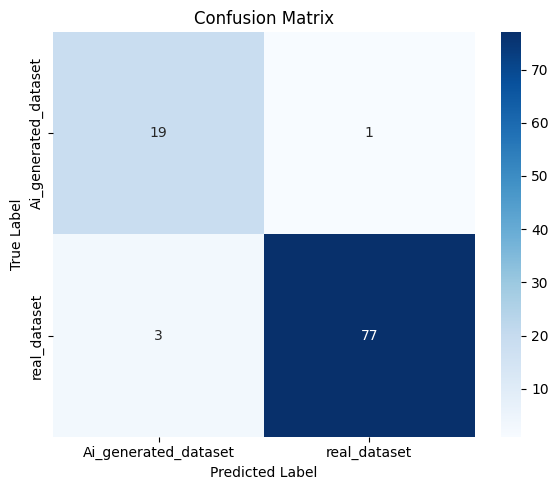

📊 Confusion matrix saved to Drive.

💾 Final model saved to: /content/drive/MyDrive/CUDA Workshop Hackathon/final_model.pth


In [7]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import time
import copy
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 2. Helper: One Training Epoch ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"   Batch [{batch_idx+1}/{len(loader)}] "
                  f"Loss: {loss.item():.4f} "
                  f"Acc: {correct/total:.4f}")

    return total_loss / len(loader), correct / total


# ── 3. Helper: Evaluation ─────────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# ── 4. Helper: Plot Training Curves ───────────────────────────────────────────
def plot_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
    ax1.set_title('Loss');  ax1.set_xlabel('Epoch')
    ax1.legend();           ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
    ax2.legend();              ax2.grid(True)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/CUDA Workshop Hackathon/training_curves.png', dpi=150)
    plt.show()
    print("📊 Training curves saved to Drive.")


# ── 5. Helper: Confusion Matrix ───────────────────────────────────────────────
def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/CUDA Workshop Hackathon/confusion_matrix.png', dpi=150)
    plt.show()
    print("📊 Confusion matrix saved to Drive.")


# ── 6. Main Training Function ─────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, optimizer, scheduler,
                criterion, device, num_epochs=15, patience=5, stage=1):

    best_val_acc      = 0.0
    best_model_wts    = copy.deepcopy(model.state_dict())
    patience_counter  = 0
    save_path         = f'/content/drive/MyDrive/CUDA Workshop Hackathon/best_model_stage{stage}.pth'

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    print(f"\n{'='*60}")
    print(f"  Stage {stage} Training — {num_epochs} epochs max, patience={patience}")
    print(f"{'='*60}\n")

    for epoch in range(1, num_epochs + 1):
        start = time.time()

        print(f"── Epoch {epoch}/{num_epochs} {'─'*40}")
        train_loss, train_acc                        = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss,   val_acc, val_preds, val_labels   = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        elapsed = time.time() - start

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n   ⏱  {elapsed:.1f}s  |  "
              f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  "
              f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            best_model_wts   = copy.deepcopy(model.state_dict())
            patience_counter = 0
            torch.save(best_model_wts, save_path)
            print(f"   ✅ New best val acc: {best_val_acc:.4f} — model saved.")
        else:
            patience_counter += 1
            print(f"   ⏳ No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch}.")
                break

    # Restore best weights
    model.load_state_dict(best_model_wts)
    print(f"\n🏆 Best Val Accuracy (Stage {stage}): {best_val_acc:.4f}")
    plot_curves(history)
    return model, history


# ── 7. Stage 1: Train Head Only (backbone frozen) ─────────────────────────────
print("🔒 Stage 1: Training classifier head with frozen backbone...\n")
model, history_stage1 = train_model(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion,
    device, num_epochs=15, patience=5, stage=1
)

# ── 8. Stage 2: Unfreeze & Fine-tune Full Model ───────────────────────────────
print("\n🔓 Stage 2: Unfreezing backbone for full fine-tuning...\n")

for param in model.parameters():
    param.requires_grad = True

optimizer_s2 = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_s2 = CosineAnnealingLR(optimizer_s2, T_max=10, eta_min=1e-7)

model, history_stage2 = train_model(
    model, train_loader, val_loader,
    optimizer_s2, scheduler_s2, criterion,
    device, num_epochs=15, patience=5, stage=2
)

# ── 9. Final Evaluation on Test Set ───────────────────────────────────────────
print("\n📋 Final Evaluation on Test Set...")
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"\n🎯 Test Loss : {test_loss:.4f}")
print(f"   Test Acc  : {test_acc:.4f}")
print(f"\n📝 Classification Report:")
print(classification_report(test_labels, test_preds, target_names=full_dataset.classes))

plot_confusion_matrix(test_labels, test_preds, full_dataset.classes)

# ── 10. Save Final Model ──────────────────────────────────────────────────────
final_path = '/content/drive/MyDrive/CUDA Workshop Hackathon/final_model.pth'
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_to_idx'     : full_dataset.class_to_idx,
    'test_accuracy'    : test_acc,
}, final_path)
print(f"\n💾 Final model saved to: {final_path}")